In [37]:
# Basic libraries 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pykalman import KalmanFilter
from itertools import combinations
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm
import pickle
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

In [38]:
# Scripts 
from scripts.src.cointegration import *
from scripts.src.kalman import *
from scripts.src.pairs import *
from scripts.src.trading_signal import *
from scripts.src.backtest import *
from scripts.src.plots import *
from scripts.src.utils import *

In [39]:
# Load in data from previous notebooks
df1_is = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/df1_is")
df1_oos = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/df1_oos")

df2_is = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/df2_is")
df2_oos = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/df2_oos")

static_results_df = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/static_hedge_ratio")
dynamic_results_df = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dynamic_hedge_ratio")

In [40]:
# Load dictionaries from previous notebook
with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/static_spreads.pkl", "rb") as f:
    static_spreads = pickle.load(f)
with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/static_models.pkl", "rb") as f:
    static_models = pickle.load(f)

with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/dynamic_spreads.pkl", "rb") as f:
    dyamic_spreads = pickle.load(f)
with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/dynamic_details.pkl", "rb") as f:
    dynamic_details = pickle.load(f)

with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/is_results.pkl", "rb") as f:
    is_results = pickle.load(f)
with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/is_trading_signals.pkl", "rb") as f:
    is_trading_signals = pickle.load(f)

## In-Sample Backtest

In [41]:
is_trading_signals 

,strategy,pair,obs_cov,entry_z,exit_z,num_trades,mean_zscore,std_zscore
0,entry_1.5_exit_0.0,700 HK Equity vs 1347 HK Equity,0.5,1.5,0.0,26.0,-0.074323,1.254340
1,entry_1.5_exit_0.0,700 HK Equity vs 1347 HK Equity,1.0,1.5,0.0,26.0,-0.075102,1.296052
2,entry_1.5_exit_0.0,700 HK Equity vs 1347 HK Equity,5.0,1.5,0.0,22.5,-0.075295,1.352083
3,entry_1.5_exit_0.0,1347 HK Equity vs 268 HK Equity,0.5,1.5,0.0,28.5,0.088018,1.284509
4,entry_1.5_exit_0.0,1347 HK Equity vs 268 HK Equity,1.0,1.5,0.0,27.5,0.090501,1.304701
...,...,...,...,...,...,...,...,...
157,entry_2.5_exit_1.0,3993 HK Equity vs 2689 HK Equity,1.0,2.5,1.0,18.5,0.079376,1.326103
158,entry_2.5_exit_1.0,3993 HK Equity vs 2689 HK Equity,5.0,2.5,1.0,18.0,0.066960,1.353544
159,entry_2.5_exit_1.0,1898 HK Equity vs 2386 HK Equity,0.5,2.5,1.0,20.0,-0.018652,1.295543
160,entry_2.5_exit_1.0,1898 HK Equity vs 2386 HK Equity,1.0,2.5,1.0,17.0,-0.025062,1.309947


In [42]:
is_summary_rows = []

for key, signals_dict in is_results.items():
    for (pair_name, R), df in signals_dict.items():

        df = compute_strategy_returns(df)

        mean_ret = df["strategy_ret"].mean()
        std_ret = df["strategy_ret"].std()

        sharpe = mean_ret / std_ret if std_ret != 0 else np.nan
        total_return = df["strategy_ret"].sum()

        is_summary_rows.append({
            "strategy": key,
            "pair": pair_name,
            "entry_z": float(key.split("_")[1]),
            "exit_z": float(key.split("_")[3]),
            "sharpe": sharpe,
            "total_return": total_return,
            "num_trades": df["position"].diff().abs().sum() / 2
        })

signals = pd.DataFrame(is_summary_rows)

In [43]:
agg_df = signals.groupby(["entry_z", "exit_z"]).agg({
    "sharpe": "mean",
    "total_return": "mean",
    "num_trades": "mean"
}).reset_index()

In [44]:
pivot_sharpe = agg_df.pivot(index="entry_z", columns="exit_z", values="sharpe")
pivot_return = agg_df.pivot(index="entry_z", columns="exit_z", values="total_return")

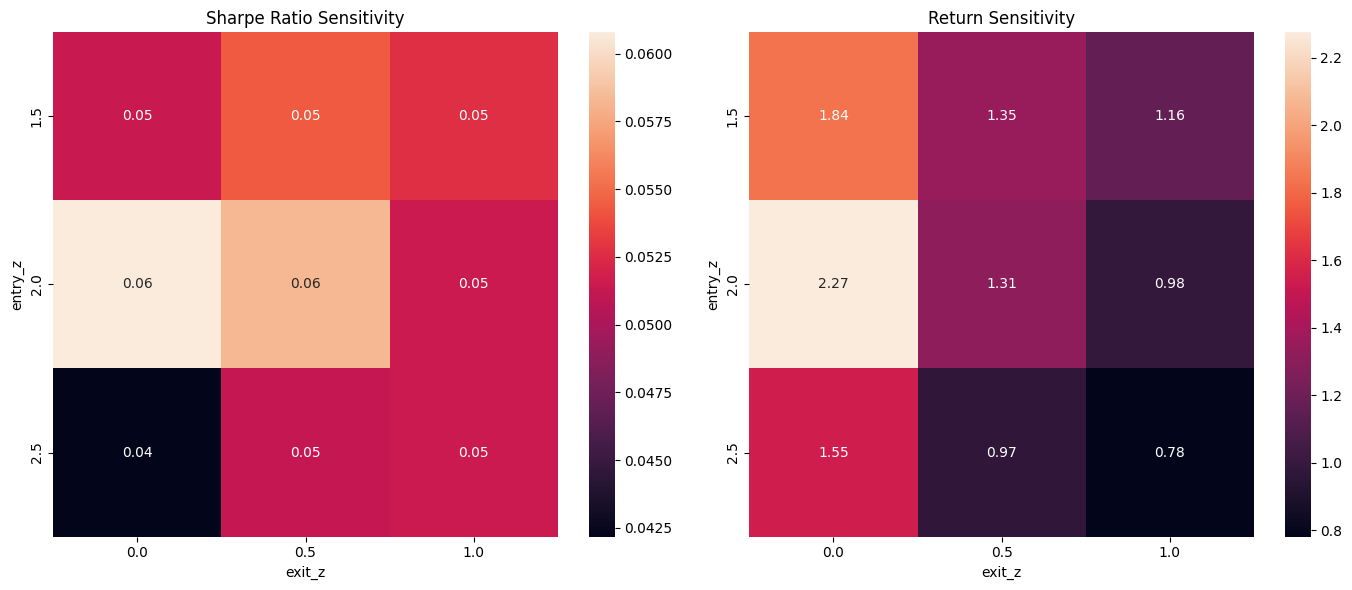

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sharpe heatmap
sns.heatmap(pivot_sharpe, annot=True, fmt=".2f", ax=axes[0])
axes[0].set_title("Sharpe Ratio Sensitivity")

# Return heatmap
sns.heatmap(pivot_return, annot=True, fmt=".2f", ax=axes[1])
axes[1].set_title("Return Sensitivity")

plt.tight_layout()
plt.show()

From our sensitivity analysis, we see that a lower entry zone suggests a higher Sharpe ratio and this could be from more trades being executed. The exit zone value dones'doesn't really make a change to the the as a

In [46]:
def plot_trade_signals(results_dict, strategy_name, pair_name, obs_cov=None, figsize=(14, 9)):
    """
    Visualise long-entry, short-entry, and exit signals for one pair.

    Parameters
    ----------
    results_dict : dict
        Nested dictionary such as results[strategy_name][(pair_name, obs_cov)] = signal_df.
    strategy_name : str
        Strategy key such as 'entry_1.0_exit_0.5'.
    pair_name : str
        Pair label used in the signal dictionary.
    obs_cov : float, optional
        Observation covariance R. If omitted, the first matching pair is used.
    """
    strategy_signals = results_dict[strategy_name]
    matching_keys = [key for key in strategy_signals if key[0] == pair_name]

    if not matching_keys:
        raise KeyError(f"Pair '{pair_name}' was not found under strategy '{strategy_name}'.")

    if obs_cov is None:
        selected_key = matching_keys[0]
    else:
        selected_key = None
        for key in matching_keys:
            if np.isclose(float(key[1]), float(obs_cov)):
                selected_key = key
                break

        if selected_key is None:
            available_r = [key[1] for key in matching_keys]
            raise KeyError(f"obs_cov={obs_cov} was not found. Available values: {available_r}")

    df = strategy_signals[selected_key].copy().sort_index()

    entry_z = float(strategy_name.split("_")[1])
    exit_z = float(strategy_name.split("_")[3])

    previous_position = df["position"].shift(1).fillna(0)
    long_entries = (df["position"] == 1) & (previous_position != 1)
    short_entries = (df["position"] == -1) & (previous_position != -1)
    exits = (df["position"] == 0) & (previous_position != 0)

    fig, axes = plt.subplots(
        2,
        1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1]}
    )

    axes[0].plot(df.index, df["spread_t"], color="steelblue", lw=1.4, label="Spread")
    axes[0].scatter(df.index[long_entries], df.loc[long_entries, "spread_t"], color="green", marker="^", s=90, label="Buy Pair / Long Spread")
    axes[0].scatter(df.index[short_entries], df.loc[short_entries, "spread_t"], color="red", marker="v", s=90, label="Sell Pair / Short Spread")
    axes[0].scatter(df.index[exits], df.loc[exits, "spread_t"], color="black", marker="x", s=70, label="Exit")
    axes[0].axhline(0, color="grey", linestyle="--", lw=1)
    axes[0].set_title(f"Trade Signals for {pair_name} | R={selected_key[1]} | {strategy_name}")
    axes[0].set_ylabel("Spread")
    axes[0].legend(loc="best")

    axes[1].plot(df.index, df["zscore"], color="darkorange", lw=1.2, label="Z-score")
    axes[1].scatter(df.index[long_entries], df.loc[long_entries, "zscore"], color="green", marker="^", s=80)
    axes[1].scatter(df.index[short_entries], df.loc[short_entries, "zscore"], color="red", marker="v", s=80)
    axes[1].scatter(df.index[exits], df.loc[exits, "zscore"], color="black", marker="x", s=60)
    axes[1].axhline(entry_z, color="red", linestyle="--", lw=1, label=f"Entry +{entry_z}")
    axes[1].axhline(-entry_z, color="green", linestyle="--", lw=1, label=f"Entry -{entry_z}")
    axes[1].axhline(exit_z, color="grey", linestyle=":", lw=1, label=f"Exit +{exit_z}")
    axes[1].axhline(-exit_z, color="grey", linestyle=":", lw=1, label=f"Exit -{exit_z}")
    axes[1].axhline(0, color="black", linestyle="-", lw=0.8)
    axes[1].set_ylabel("Z-score")
    axes[1].set_xlabel("Date")
    axes[1].legend(loc="best")

    plt.tight_layout()
    plt.show()


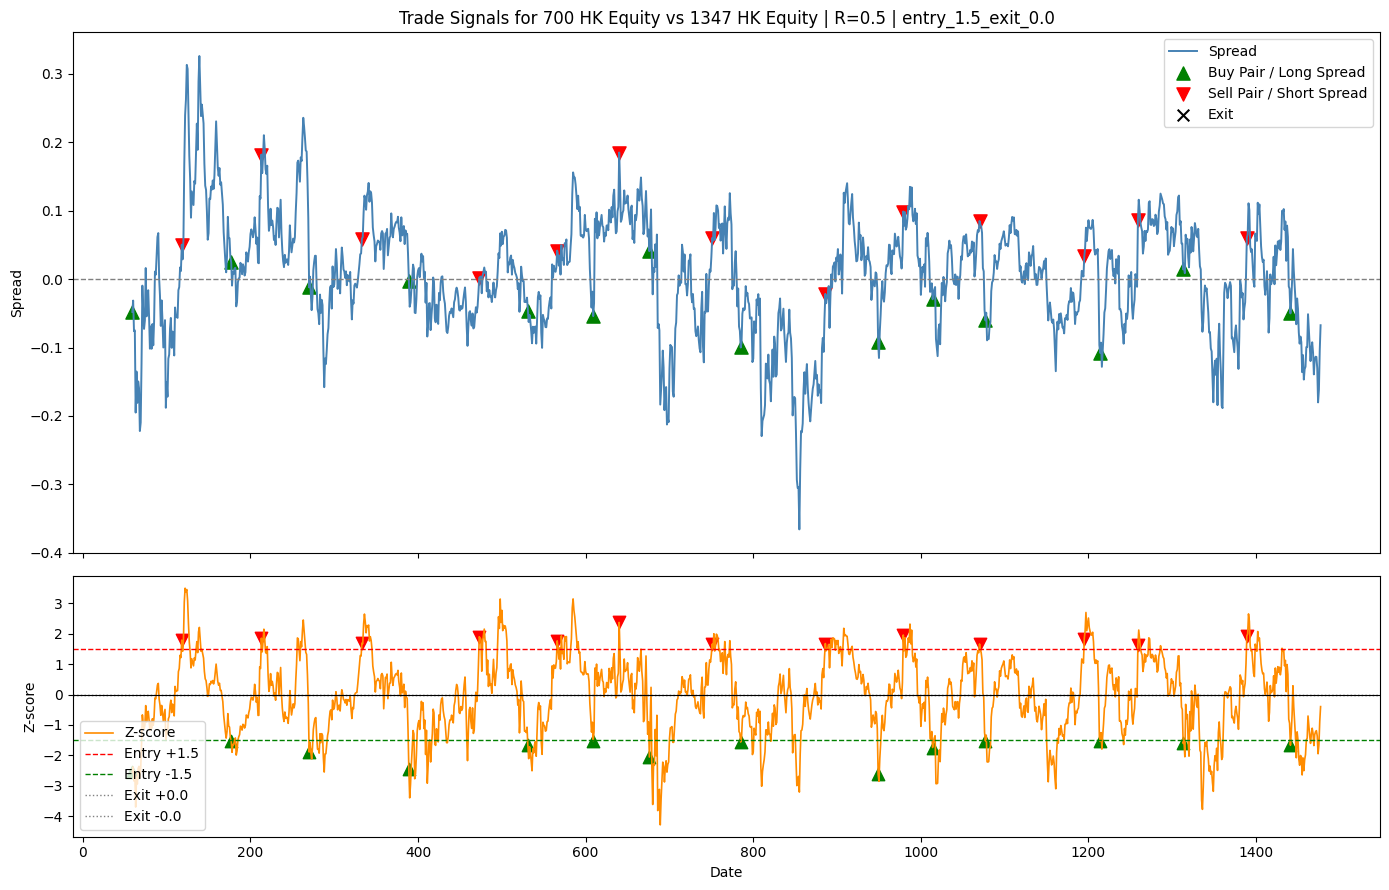

In [47]:
# Example: choose one strategy and one pair, then plot buy/sell/exit markers.
strategy_name = sorted(is_results.keys())[0]
pair_name, obs_cov = next(iter(is_results[strategy_name].keys()))

plot_trade_signals(
    results_dict=is_results,
    strategy_name=strategy_name,
    pair_name=pair_name,
    obs_cov=obs_cov
)


## OOS Backtest